# Plot model log likelihood and training curves

In [113]:
import os
import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
import ssm
from ssm.util import find_permutation

import matplotlib.colors as mc
import colorsys
import seaborn as sns
import pickle
import pandas as pd

npr.seed(0)

In [114]:
def lighten_color(color, amount=0.5):
    """
    Lightens the given color by multiplying (1-luminosity) by the given amount.
    Input can be matplotlib color string, hex string, or RGB tuple.
    From: https://stackoverflow.com/questions/37765197/darken-or-lighten-a-color-in-matplotlib
    :param color: Matplotlib color string.
    :param amount: Number between 0 and 1.
    :return:
    """

    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

### Load results

In [100]:
path_models = r'M:\analysis\Axel_Bisi\beh_model\global_glmhmm\models'
path_null_models = r'M:\analysis\Axel_Bisi\beh_model\global_glmhmm\null_models'

model_split_id = 0
iter_id = 0

res_dict = []
for model_split_id in range(10):
    for k_state in [1, 2, 3, 4, 5]:
        for iter_id in range(10):
            
            try:
                # Load models
                path_res_file = os.path.join(path_models, 'model_{}'.format(model_split_id), '{}_states'.format(k_state), 'iter_{}'.format(iter_id))
                file_name = 'global_fit_glmhmm_results.npz'
                fit_res = np.load(os.path.join(path_res_file, file_name), allow_pickle=True)
                fit_res = fit_res['arr_0'].item()
                fit_res['ll_train_list'] = fit_res['ll_train']
                fit_res['ll_train'] = fit_res['ll_train'][-1]
                fit_res['split'] = model_split_id
                fit_res['n_states'] = k_state
                fit_res['iter'] = iter_id
                fit_res['model_type'] = 'features'
                res_dict.append(fit_res)
            except FileNotFoundError:
                continue
            
            # Load null models
            try:
                path_res_file = os.path.join(path_null_models, 'model_{}'.format(model_split_id), '{}_states'.format(k_state), 'iter_{}'.format(iter_id))
                
                file_name = 'global_fit_glmhmm_results.npz'
                fit_res = np.load(os.path.join(path_res_file, file_name), allow_pickle=True)
                fit_res = fit_res['arr_0'].item()
                fit_res['ll_train_list'] = fit_res['ll_train']
                fit_res['ll_train'] = fit_res['ll_train'][-1]
                fit_res['split'] = model_split_id
                fit_res['n_states'] = k_state
                fit_res['iter'] = iter_id
                fit_res['model_type'] = 'bias only'
                res_dict.append(fit_res)
                 
            except FileNotFoundError:
                continue
    
# Make a dataframe
res_df = pd.DataFrame(res_dict)
res_df.head()

,split_idx,n_states,instance_idx,features,weights,transition_matrix,ll_train,ll_test,output_train_preds:,output_test_preds,predictive_acc_train,predictive_acc_test,ll_train_list,split,iter,model_type,covariates,chance_level_train,chance_level_test
0,0,1,0,"[prev_choice, auditory, prev_stim_auditory, wh...","[[[-1.106359217259435, -1.9874728296156812, 0....",[[1.0]],-9539.067369,-2429.156579,"[[0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, ...",0.804910,0.795945,"[-9539.067369013937, -9539.067369013937, -9539...",0,0,features,NaN,NaN,NaN
1,0,1,0,NaN,[[[0.5823804025334509]]],[[1.0]],-14035.181480,-3510.849885,"[[0], [1], [1], [0], [0], [0], [0], [0], [0], ...","[[1], [1], [1], [0], [0], [0], [0], [0], [0], ...",0.641622,0.640625,"[-14035.181479657533, -14035.181479657533, -14...",0,0,bias only,[bias],0.358378,0.359375
2,0,1,1,"[prev_choice, auditory, prev_stim_auditory, wh...","[[[-1.1063590908364882, -1.9874728192561388, 0...",[[1.0]],-9539.067369,-2429.156580,"[[0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, ...",0.804910,0.795945,"[-9539.067369013927, -9539.067369013927, -9539...",0,1,features,NaN,NaN,NaN
3,0,1,2,"[prev_choice, auditory, prev_stim_auditory, wh...","[[[-1.1063591677027635, -1.9874728239597677, 0...",[[1.0]],-9539.067369,-2429.156580,"[[0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, ...",0.804910,0.795945,"[-9539.067369013925, -9539.067369013925, -9539...",0,2,features,NaN,NaN,NaN
4,0,1,3,"[prev_choice, auditory, prev_stim_auditory, wh...","[[[-1.106359157066786, -1.9874728335531544, 0....",[[1.0]],-9539.067369,-2429.156580,"[[0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 1, ...",0.804910,0.795945,"[-9539.067369013943, -9539.067369013943, -9539...",0,3,features,NaN,NaN,NaN


In [110]:
# Load global results
path_to_global_res = r'M:\analysis\Axel_Bisi\beh_model\global_glmhmm\models'
res_df = pd.read_hdf(os.path.join(path_to_global_res, 'global_fit_glmhmm_results.h5'))
res_df['ll_train_final'] = res_df['ll_train'].apply(lambda x: x[-1])

In [94]:
res_df.loc[res_df.split_idx==0]
for i_idx in res_df.loc[res_df.split_idx==0]['instance_idx'].unique():
    print(res_df.loc[(res_df.split_idx==0) & (res_df.instance_idx==i_idx) & (res_df.model_type=='features')]['predictive_acc_test'])

0     0.795945
11    0.827753
22    0.830543
33    0.835193
44    0.851935
Name: predictive_acc_test, dtype: float64
2     0.795945
13    0.827753
24    0.833705
35    0.835379
46    0.848400
Name: predictive_acc_test, dtype: float64
3     0.795945
14    0.827753
25    0.833705
36    0.835193
47    0.848400
Name: predictive_acc_test, dtype: float64
4     0.795945
15    0.827753
26    0.830729
37    0.835379
48    0.848214
Name: predictive_acc_test, dtype: float64
5     0.795945
16    0.827753
27    0.833705
38    0.835379
49    0.838170
Name: predictive_acc_test, dtype: float64
6     0.795945
17    0.827753
28    0.833891
39    0.835379
50    0.848400
Name: predictive_acc_test, dtype: float64
7     0.795945
18    0.827753
29    0.830729
40    0.841704
51    0.838170
Name: predictive_acc_test, dtype: float64
8     0.795945
19    0.827753
30    0.833891
41    0.835379
52    0.848400
Name: predictive_acc_test, dtype: float64
9     0.795945
20    0.827753
31    0.833705
42    0.841518
53  

#### Plot mean performance 

C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated a

<Axes: title={'center': 'Accuracy on test data'}, xlabel='n_states', ylabel='predictive_acc_test'>

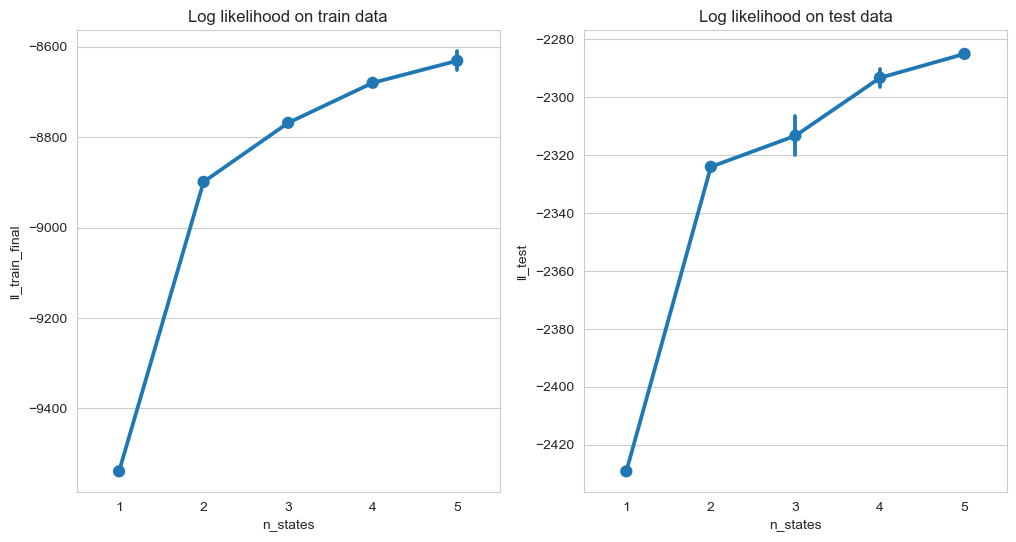

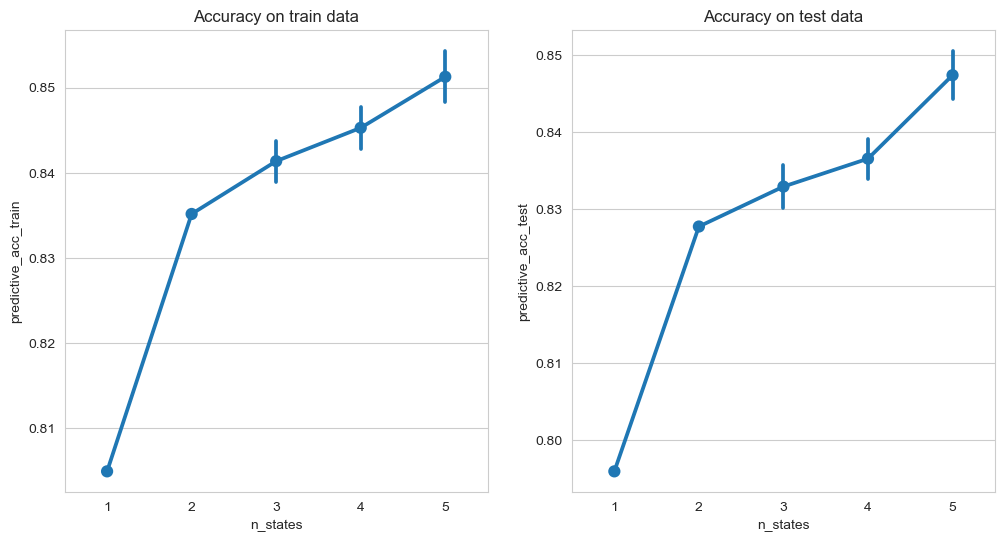

In [112]:
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    sns.set_style('whitegrid')
    # Train data
    axs[0].set_title('Log likelihood on train data')
    #sns.pointplot(x='n_states', y='ll_train', hue='model_type', data=res_df, ax=axs[0])
    sns.pointplot(x='n_states', y='ll_train_final', data=res_df, ax=axs[0], estimator=np.mean, errorbar='sd')
    
    # Test data
    axs[1].set_title('Log likelihood on test data')
    #sns.pointplot(x='n_states', y='ll_test', hue='model_type', data=res_df, ax=axs[1], estimator=np.mean, errorbar='sd')
    sns.pointplot(x='n_states', y='ll_test', data=res_df, ax=axs[1], estimator=np.mean, errorbar='sd')
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    sns.set_style('whitegrid')
    # Train data
    axs[0].set_title('Accuracy on train data')
    #sns.pointplot(x='n_states', y='predictive_acc_train', hue='model_type', data=res_df, ax=axs[0] )
    sns.pointplot(x='n_states', y='predictive_acc_train', data=res_df, ax=axs[0], estimator=np.mean, errorbar='sd')
    
    # Test data
    axs[1].set_title('Accuracy on test data')
    #sns.pointplot(x='n_states', y='predictive_acc_test', hue='model_type', data=res_df, ax=axs[1])
    sns.pointplot(x='n_states', y='predictive_acc_test', data=res_df, ax=axs[1], estimator=np.mean, errorbar='sd')


C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated a

<Axes: title={'center': 'Accuracy'}, xlabel='n_states', ylabel='predictive_acc_test'>

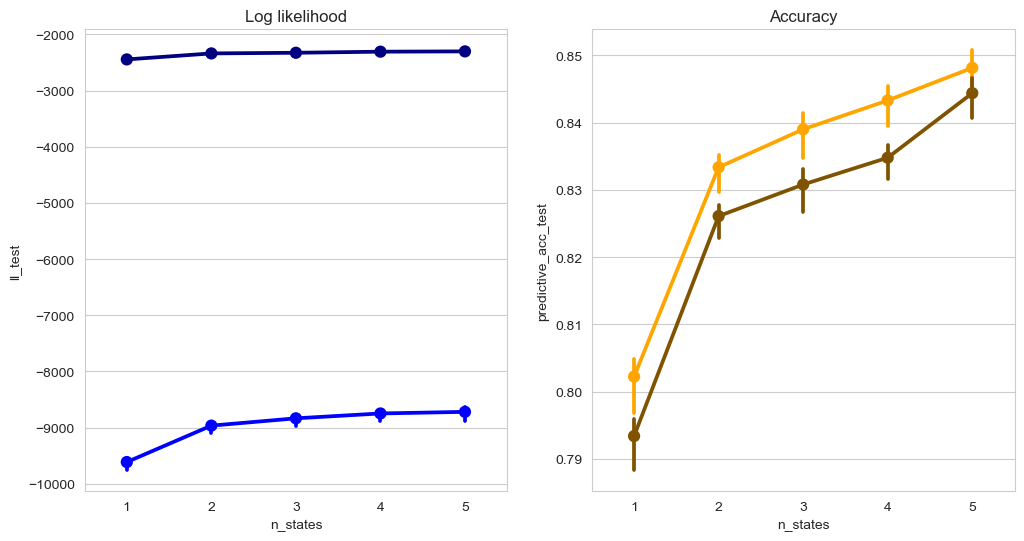

In [96]:
# Plot the same but this time comparing train vs test
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
sns.set_style('whitegrid')

axs[0].set_title('Log likelihood')
sns.pointplot(x='n_states', y='ll_train', data=res_df, ax=axs[0], color='blue')
sns.pointplot(x='n_states', y='ll_test', data=res_df, ax=axs[0], color=lighten_color('blue', 1.5))

axs[1].set_title('Accuracy')
sns.pointplot(x='n_states', y='predictive_acc_train', data=res_df, ax=axs[1], color='orange')
sns.pointplot(x='n_states', y='predictive_acc_test', data=res_df, ax=axs[1], color=lighten_color('orange', 1.5))


#### Plot training curves


C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\bisi\AppData\Local\anaconda3\envs\beh_model\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated a

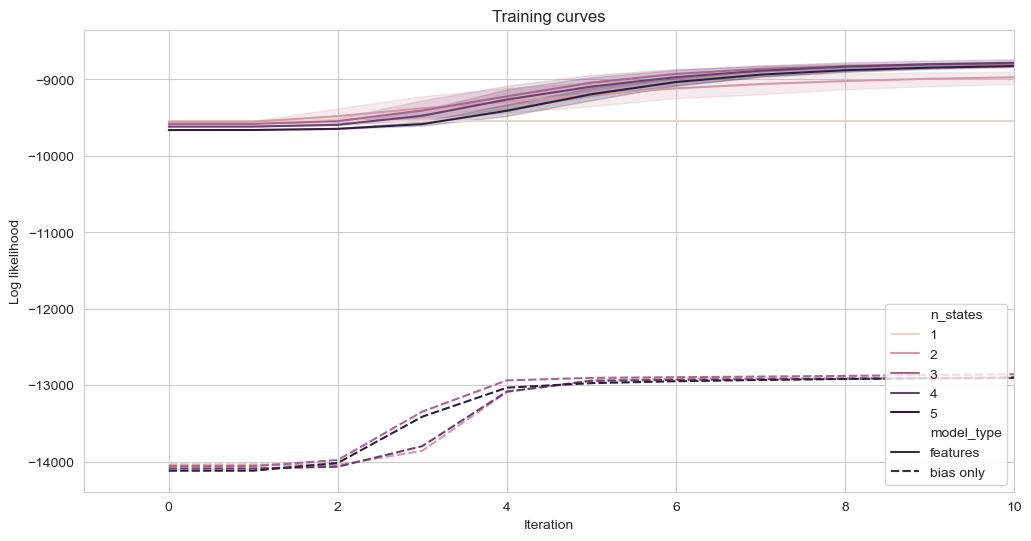

In [97]:
res_df_training = res_df[['ll_train_list', 'n_states', 'iter', 'model_type']]
res_df_training = res_df_training.explode('ll_train_list')
res_df_training['index'] = res_df_training.groupby(['n_states', 'iter', 'model_type']).cumcount()
res_df_training['ll_train_list'] = res_df_training['ll_train_list'].apply(lambda x: x.item())


fig, ax = plt.subplots(1, 1, figsize=(12, 6))
sns.set_style('whitegrid')
sns.lineplot(x='index', y='ll_train_list', hue='n_states', style='model_type', data=res_df_training, ax=ax)
ax.set_title('Training curves')
ax.set_xlabel('Iteration')
ax.set_ylabel('Log likelihood')
ax.set_xlim(-1, 10)

# Legend to the right bottom
plt.legend(loc='lower right')

